# Fraud Detection & Transaction Anomaly Analysis

This notebook extends the SQL transaction-risk framework through exploratory data analysis, behavioural feature preparation and unsupervised anomaly detection using Isolation Forest.

1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Initial Isolation Forest
4. SQL vs Python Validation
5. Behaviour-Focused Isolation Forest
6. Final Model Interpretation
7. Tableau Dataset Export

> The source dataset does not contain confirmed fraud labels. Therefore, the analysis focuses on transaction-risk patterns and statistical anomalies rather than confirmed fraud prediction.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exploratory Data Analysis (EDA)

Load the SQL Analytics Dataset

In [10]:
df = pd.read_csv("/content/fraud_analytics_dataset.csv")

## 1. Dataset Overview & Validation

In [11]:
# Preview the first records
df.head()

,SalesOrderID,CustomerID,OrderDate,order_year,order_month,order_year_month,order_value,OnlineOrderFlag,CreditCardID,previous_order_date,...,velocity_risk_points,behavioural_risk_points,geographic_risk_points,transaction_risk_score,risk_dimension_count,risk_level,risk_reason,high_risk_flag,flagged_transaction_flag,risk_level_order
0,43793,11000,2011-06-20 23:00:00,2011,6,2011-06,3756.99,1,11981.0,NaN,...,0,0,0,0,0,Low,No risk indicators,0,0,1
1,51522,11000,2013-06-19 23:00:00,2013,6,2013-06,2587.88,1,11981.0,2011-06-20 23:00:00,...,0,0,0,0,0,Low,No risk indicators,0,0,1
2,57418,11000,2013-10-02 23:00:00,2013,10,2013-10,2770.27,1,11981.0,2013-06-19 23:00:00,...,0,0,0,0,0,Low,No risk indicators,0,0,1
3,43767,11001,2011-06-16 23:00:00,2011,6,2011-06,3729.36,1,8810.0,NaN,...,0,0,0,0,0,Low,No risk indicators,0,0,1
4,51493,11001,2013-06-17 23:00:00,2013,6,2013-06,2674.02,1,8810.0,2011-06-16 23:00:00,...,0,0,0,0,0,Low,No risk indicators,0,0,1


In [12]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SalesOrderID               31465 non-null  int64  
 1   CustomerID                 31465 non-null  int64  
 2   OrderDate                  31465 non-null  object 
 3   order_year                 31465 non-null  int64  
 4   order_month                31465 non-null  int64  
 5   order_year_month           31465 non-null  object 
 6   order_value                31465 non-null  float64
 7   OnlineOrderFlag            31465 non-null  int64  
 8   CreditCardID               30334 non-null  float64
 9   previous_order_date        12346 non-null  object 
 10  days_since_previous_order  12346 non-null  float64
 11  prior_order_count          31465 non-null  int64  
 12  prior_avg_order_value      12346 non-null  float64
 13  amount_vs_customer_avg     12346 non-null  flo

In [13]:
# Dataset dimensions
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 31,465
Total Columns: 36


The dataset contains **31,465 transaction records and 36 analytical fields**.

In [16]:
# Duplicate rows
print(f"Exact duplicate rows: {df.duplicated().sum():,}")

# Duplicate transaction IDs
print(
    f"Duplicate SalesOrderID values: "
    f"{df['SalesOrderID'].duplicated().sum():,}"
)

# Missing values summary
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_summary

Exact duplicate rows: 0
Duplicate SalesOrderID values: 0


,missing_count,missing_percentage
previous_order_date,19119,60.76
prior_avg_order_value,19119,60.76
days_since_previous_order,19119,60.76
amount_vs_customer_avg,19119,60.76
CreditCardID,1131,3.59


## 2. Descriptive Statistics

In [20]:
numeric_analysis_columns = [
    "order_value",
    "days_since_previous_order",
    "prior_order_count",
    "prior_avg_order_value",
    "amount_vs_customer_avg",
    "transaction_risk_score"
]

df[numeric_analysis_columns].describe().round(2)

,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,transaction_risk_score
count,31465.00,12346.00,31465.00,12346.00,12346.00,31465.00
mean,3915.99,261.02,0.97,7796.62,1.89,0.03
std,12515.46,249.37,2.33,17455.05,53.50,0.27
min,1.52,0.00,0.00,2.53,0.00,0.00
25%,62.95,91.00,0.00,164.99,0.52,0.00
50%,865.20,138.00,0.00,2410.63,0.83,0.00
75%,2615.49,411.00,1.00,3953.99,1.20,0.00
max,187487.83,1089.00,27.00,187487.83,5908.35,5.00


## 3. Categorical Variables

In [37]:
df["risk_level"].value_counts(normalize=True)

,proportion
risk_level,
Low,0.980550
Medium,0.019132
High,0.000318


In [27]:
df["risk_reason"].value_counts().head(10)

,count
risk_reason,
No risk indicators,30853
Rapid repeat (1-7 days),368
Amount spike,163
Same-day repeat,58
City mismatch,12
"Rapid repeat (1-7 days), Amount spike",9
"Same-day repeat, Amount spike",1
State/province mismatch,1


In [36]:
df["OnlineOrderFlag"].value_counts(normalize=True)

,proportion
OnlineOrderFlag,
1,0.87904
0,0.12096


## 4. Transaction Value Analysis

This section explores the distribution of transaction values to identify skewness, extreme observations and potential high-value anomalies.

In [38]:
df["order_value"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,order_value
count,31465.00
mean,3915.99
std,12515.46
min,1.52
25%,62.95
50%,865.20
75%,2615.49
90%,3953.99
95%,20430.55
99%,69303.26


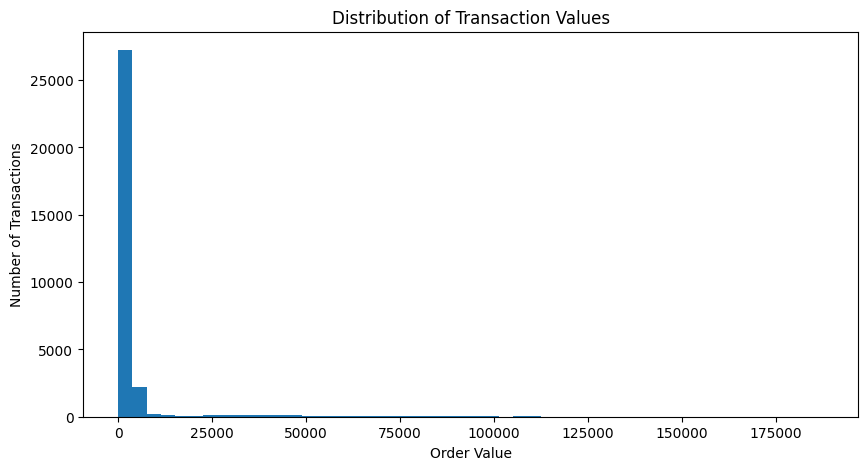

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["order_value"],
    bins=50
)

plt.title("Distribution of Transaction Values")
plt.xlabel("Order Value")
plt.ylabel("Number of Transactions")

plt.show()

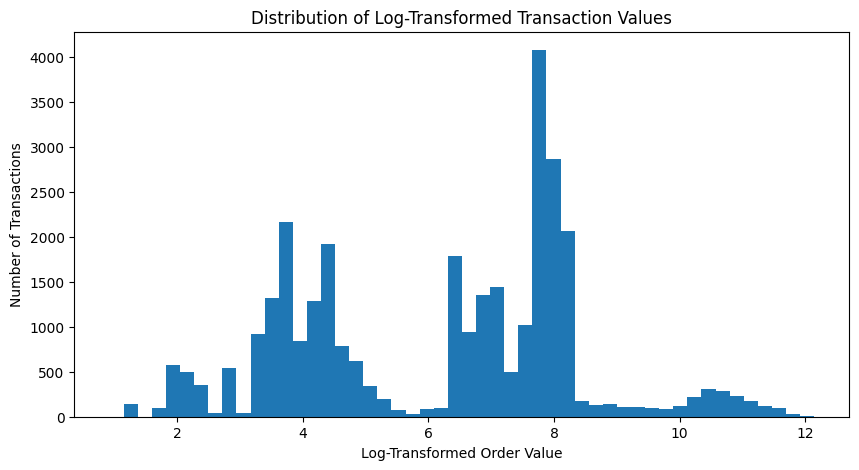

In [40]:
df["log_order_value"] = np.log1p(df["order_value"])

plt.figure(figsize=(10, 5))

plt.hist(
    df["log_order_value"],
    bins=50
)

plt.title("Distribution of Log-Transformed Transaction Values")
plt.xlabel("Log-Transformed Order Value")
plt.ylabel("Number of Transactions")

plt.show()

## 5. Customer Behavioural Deviation

Transaction values are evaluated relative to each customer`s historical purchasing behaviour.

The `amount_vs_customer_avg` feature measures how large the current transaction is compared with the customer's previous average transaction value.

In [42]:
df["amount_vs_customer_avg"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,amount_vs_customer_avg
count,12346.00
mean,1.89
std,53.50
min,0.00
50%,0.83
75%,1.20
90%,2.28
95%,3.14
99%,11.43
max,5908.35


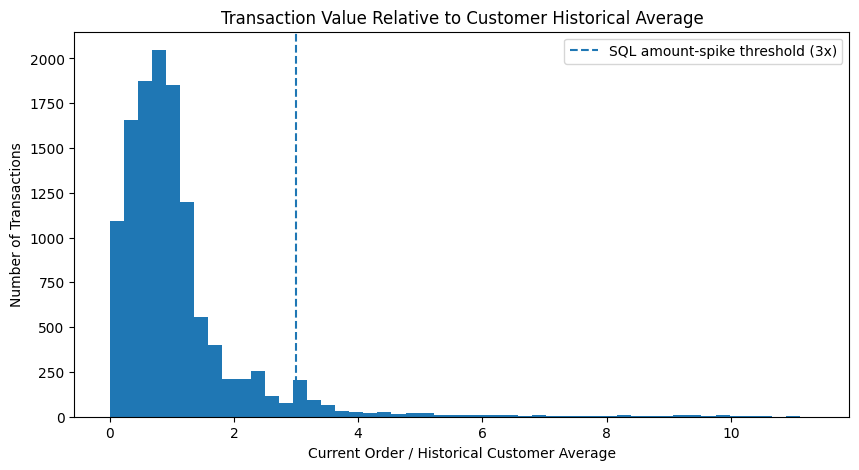

In [43]:
amount_ratio_plot = df[
    df["amount_vs_customer_avg"].between(
        0,
        df["amount_vs_customer_avg"].quantile(0.99)
    )
]["amount_vs_customer_avg"]

plt.figure(figsize=(10, 5))

plt.hist(
    amount_ratio_plot.dropna(),
    bins=50
)

plt.axvline(
    3,
    linestyle="--",
    label="SQL amount-spike threshold (3x)"
)

plt.title("Transaction Value Relative to Customer Historical Average")
plt.xlabel("Current Order / Historical Customer Average")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

## 6. Transaction Velocity Analysis

The time between consecutive customer transactions is analysed to identify unusually rapid purchasing activity.

In [44]:
df["days_since_previous_order"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,days_since_previous_order
count,12346.00
mean,261.02
std,249.37
min,0.00
25%,91.00
50%,138.00
75%,411.00
90%,634.50
95%,780.75
99%,981.00


In [45]:
velocity_segments = pd.cut(
    df["days_since_previous_order"],
    bins=[-1, 0, 7, 30, 90, float("inf")],
    labels=[
        "Same day",
        "1-7 days",
        "8-30 days",
        "31-90 days",
        "More than 90 days"
    ]
)

velocity_segments.value_counts().reindex([
    "Same day",
    "1-7 days",
    "8-30 days",
    "31-90 days",
    "More than 90 days"
])

,count
days_since_previous_order,
Same day,59
1-7 days,377
8-30 days,828
31-90 days,1815
More than 90 days,9267


## 7. Risk Indicator Analysis

The frequency of each SQL-generated risk indicator is compared to understand which transaction-risk signals occur most frequently.

In [47]:
risk_flags = [
    "same_day_repeat_flag",
    "rapid_repeat_flag",
    "amount_spike_flag",
    "city_mismatch_flag",
    "state_mismatch_flag"
]

risk_flag_counts = df[risk_flags].sum().sort_values(ascending=False)

risk_flag_counts

,0
rapid_repeat_flag,377
amount_spike_flag,173
same_day_repeat_flag,59
city_mismatch_flag,13
state_mismatch_flag,1


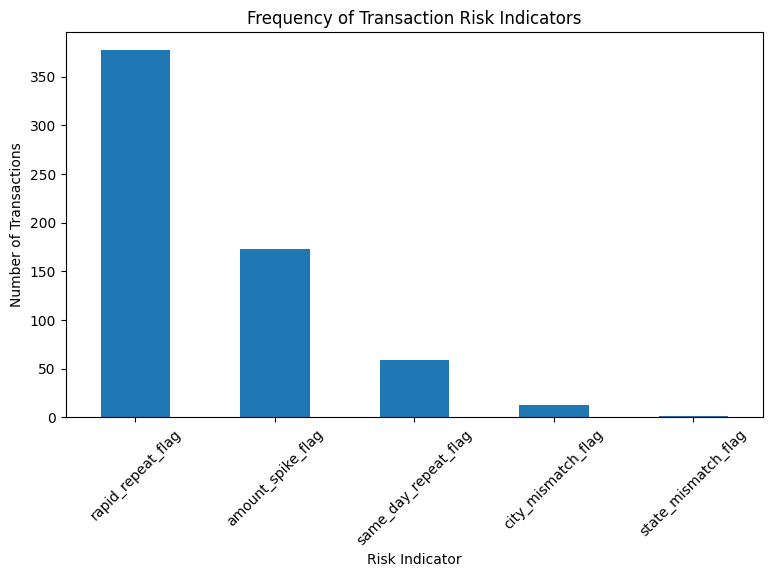

In [48]:
plt.figure(figsize=(9, 5))

risk_flag_counts.plot(kind="bar")

plt.title("Frequency of Transaction Risk Indicators")
plt.xlabel("Risk Indicator")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

## 8. SQL Risk Score Analysis

The distribution of the rule-based SQL risk score is analysed to understand how transactions are prioritised across different levels of investigation risk.

In [49]:
risk_score_distribution = (
    df["transaction_risk_score"]
    .value_counts()
    .sort_index()
)

risk_score_distribution

,count
transaction_risk_score,
0,30853
1,380
2,59
3,163
4,9
5,1


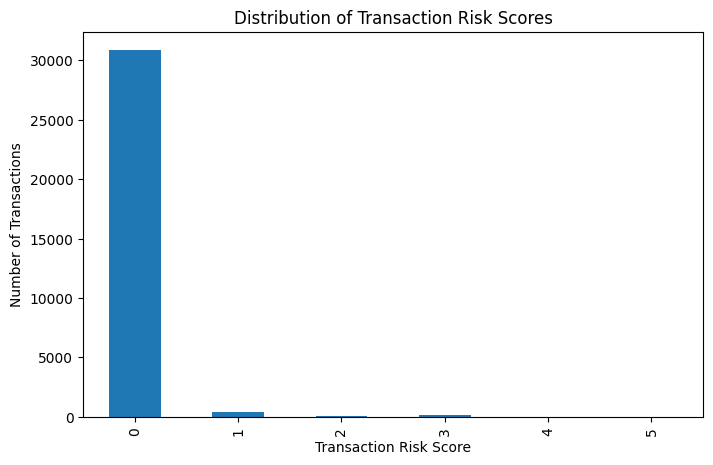

In [50]:
plt.figure(figsize=(8, 5))

risk_score_distribution.plot(kind="bar")

plt.title("Distribution of Transaction Risk Scores")
plt.xlabel("Transaction Risk Score")
plt.ylabel("Number of Transactions")

plt.show()

In [51]:
risk_level_distribution = (
    df["risk_level"]
    .value_counts()
    .reindex(["High", "Medium", "Low"])
)

risk_level_distribution

,count
risk_level,
High,10
Medium,602
Low,30853


## 9. Transaction Behaviour by Risk Level

Transaction characteristics are compared across SQL risk levels to understand how behavioural and value-based patterns differ between low-, medium- and high-priority transactions.

In [52]:
risk_level_summary = (
    df.groupby("risk_level")
      .agg(
          transaction_count=("SalesOrderID", "count"),
          avg_order_value=("order_value", "mean"),
          median_order_value=("order_value", "median"),
          avg_days_since_previous_order=("days_since_previous_order", "mean"),
          avg_amount_vs_customer_avg=("amount_vs_customer_avg", "mean"),
          avg_risk_score=("transaction_risk_score", "mean")
      )
      .round(2)
)

risk_level_summary

,transaction_count,avg_order_value,median_order_value,avg_days_since_previous_order,avg_amount_vs_customer_avg,avg_risk_score
risk_level,,,,,,
High,10,135.01,141.38,3.20,4.16,4.10
Low,30853,3900.27,865.20,272.95,1.82,0.00
Medium,602,4784.53,76.21,28.29,3.32,1.64


## 10. High-Priority Transaction Review

The transactions classified as High risk by the SQL framework are reviewed individually to understand which combinations of behavioural signals drove their prioritisation.

In [53]:
high_risk_transactions = (
    df[df["risk_level"] == "High"]
    .sort_values(
        by=["transaction_risk_score", "amount_vs_customer_avg"],
        ascending=[False, False]
    )
)

high_risk_transactions[
    [
        "SalesOrderID",
        "CustomerID",
        "OrderDate",
        "order_value",
        "days_since_previous_order",
        "prior_order_count",
        "prior_avg_order_value",
        "amount_vs_customer_avg",
        "transaction_risk_score",
        "risk_reason"
    ]
]

,SalesOrderID,CustomerID,OrderDate,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,transaction_risk_score,risk_reason
2059,56087,11641,2013-09-11 23:00:00,159.64,0.0,2,50.53,3.16,5,"Same-day repeat, Amount spike"
1588,55101,11498,2013-08-26 23:00:00,66.28,5.0,2,7.15,9.27,4,"Rapid repeat (1-7 days), Amount spike"
4522,68276,12704,2014-03-14 23:00:00,175.70,3.0,2,32.30,5.44,4,"Rapid repeat (1-7 days), Amount spike"
941,64317,11276,2014-01-15 23:00:00,141.38,1.0,10,36.28,3.90,4,"Rapid repeat (1-7 days), Amount spike"
8158,68292,14611,2014-03-14 23:00:00,216.13,5.0,2,60.20,3.59,4,"Rapid repeat (1-7 days), Amount spike"
2233,60133,11711,2013-11-13 23:00:00,76.21,6.0,8,23.03,3.31,4,"Rapid repeat (1-7 days), Amount spike"
1659,55462,11505,2013-08-31 23:00:00,126.48,5.0,3,38.69,3.27,4,"Rapid repeat (1-7 days), Amount spike"
520,74634,11176,2014-06-14 23:00:00,159.64,1.0,25,49.14,3.25,4,"Rapid repeat (1-7 days), Amount spike"
1589,55158,11498,2013-08-27 23:00:00,87.27,1.0,3,26.86,3.25,4,"Rapid repeat (1-7 days), Amount spike"
892,66099,11262,2014-02-09 23:00:00,141.38,5.0,14,44.72,3.16,4,"Rapid repeat (1-7 days), Amount spike"


### EDA Findings

The exploratory analysis shows that the SQL risk framework identifies a relatively small subset of transactions with unusual behavioural characteristics.

High-priority transactions are not necessarily the transactions with the highest absolute values. Instead, many are characterised by a combination of:

- unusually short time intervals between consecutive purchases;
- transaction values substantially above the customer's historical average;
- multiple simultaneous behavioural risk signals.

The highest-priority transaction combines same-day repeat activity with an amount spike, resulting in the maximum observed SQL risk score.

These findings support the use of customer-specific behavioural baselines rather than relying exclusively on global transaction-value thresholds.

# Data Preprocessing for Anomaly Detection

The preprocessing stage prepares the analytical dataset for unsupervised anomaly detection.

Unlike conventional predictive modelling, unusual but valid observations are deliberately preserved because they may represent the anomalies the model is intended to detect.

SQL-generated risk scores, risk classifications and rule-based indicators are excluded from the model features to allow an independent comparison between the SQL risk framework and the Python anomaly-detection model.

In [56]:
# Create modelling copy
df_model = df.copy()

print(f"Modelling dataset: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns")

df_model

Modelling dataset: 31,465 rows × 37 columns


,SalesOrderID,CustomerID,OrderDate,order_year,order_month,order_year_month,order_value,OnlineOrderFlag,CreditCardID,previous_order_date,...,behavioural_risk_points,geographic_risk_points,transaction_risk_score,risk_dimension_count,risk_level,risk_reason,high_risk_flag,flagged_transaction_flag,risk_level_order,log_order_value
0,43793,11000,2011-06-20 23:00:00,2011,6,2011-06,3756.99,1,11981.0,NaN,...,0,0,0,0,Low,No risk indicators,0,0,1,8.231640
1,51522,11000,2013-06-19 23:00:00,2013,6,2013-06,2587.88,1,11981.0,2011-06-20 23:00:00,...,0,0,0,0,Low,No risk indicators,0,0,1,7.858981
2,57418,11000,2013-10-02 23:00:00,2013,10,2013-10,2770.27,1,11981.0,2013-06-19 23:00:00,...,0,0,0,0,Low,No risk indicators,0,0,1,7.927061
3,43767,11001,2011-06-16 23:00:00,2011,6,2011-06,3729.36,1,8810.0,NaN,...,0,0,0,0,Low,No risk indicators,0,0,1,8.224260
4,51493,11001,2013-06-17 23:00:00,2013,6,2013-06,2674.02,1,8810.0,2011-06-16 23:00:00,...,0,0,0,0,Low,No risk indicators,0,0,1,7.891712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31460,50675,30118,2013-04-29 23:00:00,2013,4,2013-04,43214.85,0,16569.0,2013-01-27 23:00:00,...,0,0,0,0,Low,No risk indicators,0,0,1,10.673963
31461,53480,30118,2013-07-30 23:00:00,2013,7,2013-07,49576.74,0,16569.0,2013-04-29 23:00:00,...,0,0,0,0,Low,No risk indicators,0,0,1,10.811297
31462,58928,30118,2013-10-29 23:00:00,2013,10,2013-10,40248.24,0,16569.0,2013-07-30 23:00:00,...,0,0,0,0,Low,No risk indicators,0,0,1,10.602846
31463,65221,30118,2014-01-28 23:00:00,2014,1,2014-01,27290.95,0,16569.0,2013-10-29 23:00:00,...,0,0,0,0,Low,No risk indicators,0,0,1,10.214347


## 1. Feature Selection

The anomaly-detection model is intentionally built using behavioural transaction variables rather than the SQL-generated risk score or rule-based risk flags.

This prevents information leakage and enables an independent comparison between rule-based SQL risk detection and data-driven anomaly detection.

In [61]:
# Select model features
model_features = [
    "order_value",
    "days_since_previous_order",
    "prior_order_count",
    "prior_avg_order_value",
    "amount_vs_customer_avg",
    "OnlineOrderFlag"
]

# Create feature dataset
X = df_model[model_features].copy()

X.head()

,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,OnlineOrderFlag
0,3756.99,NaN,0,NaN,NaN,1
1,2587.88,730.0,1,3756.99,0.69,1
2,2770.27,105.0,2,3172.43,0.87,1
3,3729.36,NaN,0,NaN,NaN,1
4,2674.02,732.0,1,3729.36,0.72,1


In [62]:
# Check missing values
X.isnull().sum()

,0
order_value,0
days_since_previous_order,19119
prior_order_count,0
prior_avg_order_value,19119
amount_vs_customer_avg,19119
OnlineOrderFlag,0


In [60]:
X.dropna()

,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,OnlineOrderFlag
1,2587.88,730.0,1,3756.99,0.69,1
2,2770.27,105.0,2,3172.43,0.87,1
4,2674.02,732.0,1,3729.36,0.72,1
5,650.80,328.0,2,3201.69,0.20,1
7,2535.96,724.0,1,3756.99,0.67,1
...,...,...,...,...,...,...
31460,43214.85,92.0,3,38820.83,1.11,0
31461,49576.74,92.0,4,39919.33,1.24,0
31462,40248.24,91.0,5,41850.82,0.96,0
31463,27290.95,91.0,6,41583.72,0.66,0


### Historical Behaviour Availability

Missing values in the historical behaviour features are expected rather than data-quality errors.

For a customer's first recorded transaction, no previous order or historical spending baseline exists. Since the anomaly-detection model relies on customer behavioural history, transactions without prior history are excluded from the modelling sample rather than artificially imputed.

The original analytical dataset remains unchanged.

In [63]:
# Identify first orders
first_orders = X["prior_order_count"] == 0

print(f"First transactions: {first_orders.sum():,}")

First transactions: 19,119


In [64]:
# Filter historical transactions
X_model = X.loc[X["prior_order_count"] > 0].copy()

print(f"Model rows: {X_model.shape[0]:,}")

Model rows: 12,346


In [65]:
# Recheck missing values
X_model.isnull().sum()

,0
order_value,0
days_since_previous_order,0
prior_order_count,0
prior_avg_order_value,0
amount_vs_customer_avg,0
OnlineOrderFlag,0


## 2. Feature Transformation

Highly skewed numerical variables are log-transformed to reduce the influence of extreme magnitudes while preserving unusual observations.

Extreme transactions are not removed, as they may represent the anomalies the model is intended to identify.

In [70]:
# Create transformed dataset
X_processed = X_model.copy()

# Log-transform features
log_features = [
    "order_value",
    "days_since_previous_order",
    "prior_avg_order_value",
    "amount_vs_customer_avg"
]

for column in log_features:
    X_processed[column] = np.log1p(X_processed[column])

In [71]:
# Review transformed data
X_processed.describe().round(2)

,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,OnlineOrderFlag
count,12346.00,12346.00,12346.00,12346.00,12346.00,12346.00
mean,6.90,4.99,2.47,7.15,0.68,0.74
std,2.24,1.27,3.18,2.23,0.47,0.44
min,1.26,0.00,1.00,1.26,0.00,0.00
25%,4.92,4.52,1.00,5.11,0.42,0.00
50%,7.54,4.93,1.00,7.79,0.60,1.00
75%,7.90,6.02,2.00,8.28,0.79,1.00
max,12.11,6.99,27.00,12.14,8.68,1.00


## 3. Feature Scaling

Numerical features are standardised before anomaly detection so that differences in measurement scale do not disproportionately influence the modelling process.

In [75]:
# Import scaler
from sklearn.preprocessing import StandardScaler

# Scale model features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_processed)
X_scaled

array([[ 0.43079885,  1.2672018 , -0.46132034,  0.48577393, -0.32854793,
         0.58788866],
       [ 0.46122926, -0.25836523, -0.14677564,  0.40986635, -0.11100753,
         0.58788866],
       [ 0.44542911,  1.26936041, -0.46132034,  0.48246077, -0.29072763,
         0.58788866],
       ...,
       [ 1.65724648, -0.37027627,  0.79685847,  1.56789977, -0.00997281,
        -1.70100236],
       [ 1.48359583, -0.37027627,  1.11140318,  1.56502526, -0.36704565,
        -1.70100236],
       [ 1.61816205, -0.36173511,  1.42594788,  1.54242111, -0.04312615,
        -1.70100236]])

In [76]:
# Restore feature names
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_processed.columns,
    index=X_processed.index
)

X_scaled.head()

,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,OnlineOrderFlag
1,0.430799,1.267202,-0.461320,0.485774,-0.328548,0.587889
2,0.461229,-0.258365,-0.146776,0.409866,-0.111008,0.587889
4,0.445429,1.269360,-0.461320,0.482461,-0.290728,0.587889
5,-0.185692,0.636461,-0.146776,0.413987,-1.064517,0.587889
7,0.421744,1.260690,-0.461320,0.485774,-0.354136,0.587889


In [77]:
# Validate scaled features
X_scaled.agg(["mean", "std"]).round(2)

,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,OnlineOrderFlag
mean,0.0,-0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


# Unsupervised Anomaly Detection

## 4. Isolation Forest

Isolation Forest is applied to identify transactions whose behavioural characteristics differ substantially from the broader transaction population.

The model is trained only on behavioural transaction features and does not use the SQL-generated risk score, risk level or rule-based risk indicators. This allows the model to provide an independent anomaly-detection perspective.

In [79]:
# Import model
from sklearn.ensemble import IsolationForest

# Create Isolation Forest
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42
)

# Train model
isolation_forest.fit(X_scaled)

IsolationForest(n_estimators=300, random_state=42)

In [81]:
# Predict anomalies
anomaly_prediction = isolation_forest.predict(X_scaled)

# Calculate anomaly scores
anomaly_score = -isolation_forest.decision_function(X_scaled)

## 5. Model Results

The Isolation Forest predictions and anomaly scores are mapped back to the original transaction records while preserving the original dataset index.

In [86]:
# Create results dataset
model_results = df_model.loc[X_model.index].copy()

# Add model predictions
model_results["anomaly_prediction"] = anomaly_prediction
model_results["anomaly_score"] = anomaly_score

# Create anomaly flag
model_results["anomaly_flag"] = (
    model_results["anomaly_prediction"] == -1
).astype(int)

# Count model anomalies
model_results["anomaly_flag"].value_counts()

,count
anomaly_flag,
0,9439
1,2907


In [87]:
# Calculate anomaly rate
model_results["anomaly_flag"].value_counts(
    normalize=True
).mul(100).round(2)

,proportion
anomaly_flag,
0,76.45
1,23.55


In [89]:
# Review top anomalies
top_anomalies = (
    model_results[
        model_results["anomaly_flag"] == 1
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

top_anomalies[
    [
        "SalesOrderID",
        "CustomerID",
        "OrderDate",
        "order_value",
        "days_since_previous_order",
        "prior_order_count",
        "prior_avg_order_value",
        "amount_vs_customer_avg",
        "anomaly_score"
    ]
].head(10)

,SalesOrderID,CustomerID,OrderDate,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,anomaly_score
31322,46640,30096,2012-05-29 23:00:00,37508.56,273.0,1,6.35,5908.35,0.203655
562,71107,11185,2014-04-20 23:00:00,2.53,1.0,23,63.85,0.04,0.196088
520,74634,11176,2014-06-14 23:00:00,159.64,1.0,25,49.14,3.25,0.188887
621,74855,11200,2014-06-21 23:00:00,2.53,11.0,26,62.10,0.04,0.187908
2049,68712,11638,2014-03-20 23:00:00,82.85,0.0,1,2.53,32.74,0.184459
27773,51137,29500,2013-05-29 23:00:00,52291.52,181.0,3,225.39,232.01,0.183508
29413,69483,29766,2014-03-30 23:00:00,1550.50,455.0,1,25.39,61.07,0.177660
29240,45523,29733,2012-01-28 23:00:00,1614.52,181.0,1,12.70,127.16,0.177289
14175,52025,18293,2013-07-02 23:00:00,79.50,3.0,1,2.53,31.42,0.171799
2250,74887,11711,2014-06-22 23:00:00,5.51,6.0,25,45.78,0.12,0.170784


In [90]:
model_results["anomaly_flag"].value_counts()

,count
anomaly_flag,
0,9439
1,2907


In [91]:
model_results["anomaly_flag"].value_counts(
    normalize=True
).mul(100).round(2)

,proportion
anomaly_flag,
0,76.45
1,23.55


### Automatic Isolation Forest Threshold

Using the default automatic threshold, Isolation Forest classified 2,907 transactions (23.55% of the modelling sample) as anomalous.

This threshold is considered too broad for transaction-investigation prioritisation. Therefore, the binary prediction is retained for reference, while the continuous anomaly score is used as the primary model output for ranking unusual transactions.

## 6. Anomaly Score Analysis

The continuous Isolation Forest anomaly score is analysed instead of relying exclusively on the model's automatic binary classification.

Higher anomaly scores represent transactions that are more unusual relative to the behavioural patterns observed in the modelling population.

In [92]:
# Review anomaly scores
model_results["anomaly_score"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(4)

,anomaly_score
count,12346.0000
mean,-0.0441
std,0.0636
min,-0.1309
50%,-0.0557
75%,-0.0039
90%,0.0466
95%,0.0758
99%,0.1286
max,0.2037


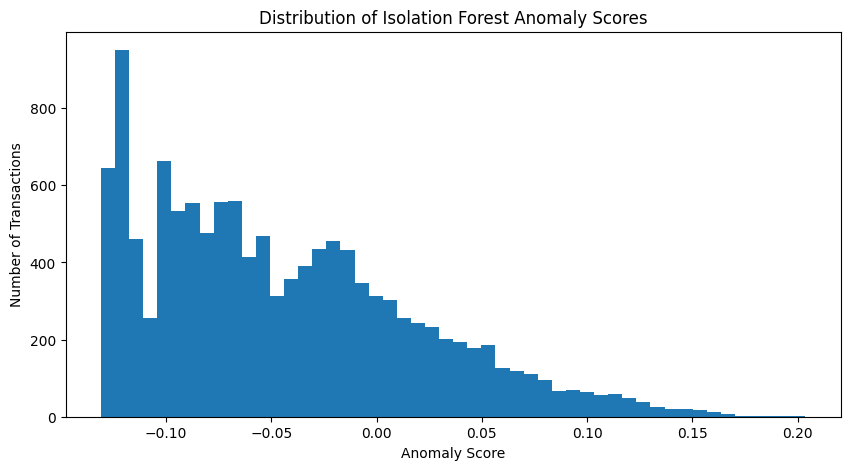

In [93]:
# Plot anomaly scores
plt.figure(figsize=(10, 5))

plt.hist(
    model_results["anomaly_score"],
    bins=50
)

plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Transactions")

plt.show()

In [98]:
# Create anomaly percentile
model_results["anomaly_percentile"] = (
    model_results["anomaly_score"]
    .rank(pct=True)
)

# Create review thresholds
model_results["top_1pct_anomaly"] = (
    model_results["anomaly_percentile"] >= 0.99
).astype(int)

model_results["top_5pct_anomaly"] = (
    model_results["anomaly_percentile"] >= 0.95
).astype(int)

model_results["top_10pct_anomaly"] = (
    model_results["anomaly_percentile"] >= 0.90
).astype(int)

# Count priority groups
print(
    "Top 1%:",
    model_results["top_1pct_anomaly"].sum()
)

print(
    "Top 5%:",
    model_results["top_5pct_anomaly"].sum()
)

print(
    "Top 10%:",
    model_results["top_10pct_anomaly"].sum()
)

Top 1%: 124
Top 5%: 618
Top 10%: 1235


## 7. SQL vs Python Risk Comparison

The independently generated Python anomaly scores are compared with the SQL rule-based risk classifications.

This comparison evaluates whether transactions prioritised through transparent behavioural rules also appear unusual from an unsupervised machine-learning perspective.

In [99]:
# Compare risk levels
pd.crosstab(
    model_results["risk_level"],
    model_results["anomaly_flag"]
)

anomaly_flag,0,1
risk_level,,
High,0,10
Low,9394,2351
Medium,45,546


In [100]:
# Compare top anomalies
sql_python_comparison = (
    model_results
    .groupby("risk_level")
    .agg(
        transactions=("SalesOrderID", "count"),
        avg_anomaly_score=("anomaly_score", "mean"),
        top_1pct=("top_1pct_anomaly", "sum"),
        top_5pct=("top_5pct_anomaly", "sum"),
        top_10pct=("top_10pct_anomaly", "sum")
    )
    .round(4)
)

sql_python_comparison

,transactions,avg_anomaly_score,top_1pct,top_5pct,top_10pct
risk_level,,,,,
High,10,0.1003,2,8,10
Low,11745,-0.0497,51,387,866
Medium,591,0.0640,71,223,359


### Cross-Method Agreement

The comparison shows strong alignment between the independently developed SQL risk framework and the Isolation Forest anomaly model.

Transactions assigned higher SQL risk levels also exhibit substantially higher Python anomaly scores and are disproportionately represented among the most unusual transactions identified by the model.

In [101]:
# Calculate overlap rates
comparison_rates = sql_python_comparison.copy()

comparison_rates["top_1pct_rate"] = (
    comparison_rates["top_1pct"] /
    comparison_rates["transactions"] * 100
).round(2)

comparison_rates["top_5pct_rate"] = (
    comparison_rates["top_5pct"] /
    comparison_rates["transactions"] * 100
).round(2)

comparison_rates["top_10pct_rate"] = (
    comparison_rates["top_10pct"] /
    comparison_rates["transactions"] * 100
).round(2)

comparison_rates[
    [
        "avg_anomaly_score",
        "top_1pct_rate",
        "top_5pct_rate",
        "top_10pct_rate"
    ]
]

,avg_anomaly_score,top_1pct_rate,top_5pct_rate,top_10pct_rate
risk_level,,,,
High,0.1003,20.00,80.00,100.00
Low,-0.0497,0.43,3.30,7.37
Medium,0.0640,12.01,37.73,60.74


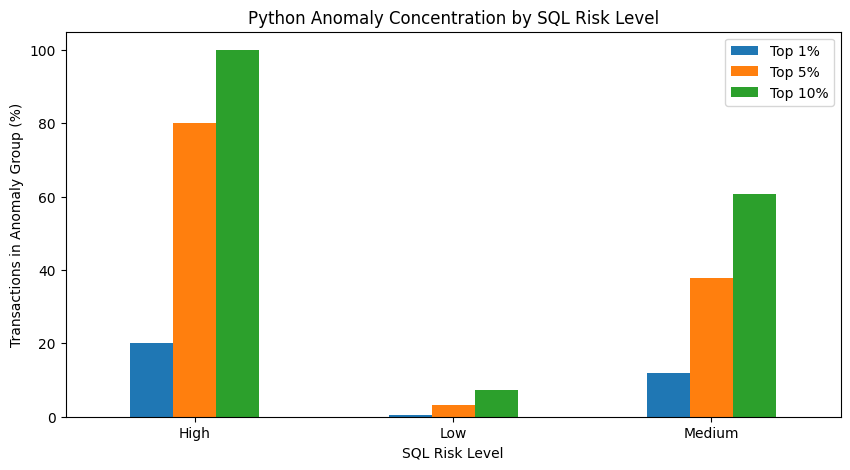

In [102]:
# Plot overlap rates
comparison_rates[
    [
        "top_1pct_rate",
        "top_5pct_rate",
        "top_10pct_rate"
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Python Anomaly Concentration by SQL Risk Level")
plt.xlabel("SQL Risk Level")
plt.ylabel("Transactions in Anomaly Group (%)")
plt.xticks(rotation=0)
plt.legend(
    ["Top 1%", "Top 5%", "Top 10%"]
)

plt.show()

In [104]:
# Review model-only anomalies
python_only_anomalies = (
    model_results[
        (model_results["risk_level"] == "Low") &
        (model_results["top_1pct_anomaly"] == 1)
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

python_only_anomalies[
    [
        "SalesOrderID",
        "CustomerID",
        "OrderDate",
        "order_value",
        "days_since_previous_order",
        "prior_order_count",
        "prior_avg_order_value",
        "amount_vs_customer_avg",
        "anomaly_score",
        "risk_reason"
    ]
].head(10)

,SalesOrderID,CustomerID,OrderDate,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,anomaly_score,risk_reason
31322,46640,30096,2012-05-29 23:00:00,37508.56,273.0,1,6.35,5908.35,0.203655,No risk indicators
621,74855,11200,2014-06-21 23:00:00,2.53,11.0,26,62.10,0.04,0.187908,No risk indicators
29413,69483,29766,2014-03-30 23:00:00,1550.50,455.0,1,25.39,61.07,0.177660,No risk indicators
29240,45523,29733,2012-01-28 23:00:00,1614.52,181.0,1,12.70,127.16,0.177289,No risk indicators
27717,50734,29492,2013-04-29 23:00:00,2521.97,182.0,1,23.18,108.81,0.170074,No risk indicators
28949,49064,29691,2012-12-30 23:00:00,9186.18,184.0,1,236.35,38.87,0.165644,No risk indicators
751,72881,11223,2014-05-13 23:00:00,5.51,15.0,25,50.87,0.11,0.163174,No risk indicators
746,70103,11223,2014-04-06 23:00:00,2.53,18.0,20,56.76,0.04,0.161123,No risk indicators
29362,44481,29757,2011-09-30 23:00:00,29689.35,92.0,1,76.18,389.72,0.159366,No risk indicators
1159,71105,11330,2014-04-20 23:00:00,2.53,20.0,21,48.27,0.05,0.159098,No risk indicators


In [105]:
# Review SQL high risk
high_risk_comparison = (
    model_results[
        model_results["risk_level"] == "High"
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

high_risk_comparison[
    [
        "SalesOrderID",
        "CustomerID",
        "order_value",
        "days_since_previous_order",
        "amount_vs_customer_avg",
        "transaction_risk_score",
        "anomaly_score",
        "anomaly_percentile",
        "risk_reason"
    ]
]

,SalesOrderID,CustomerID,order_value,days_since_previous_order,amount_vs_customer_avg,transaction_risk_score,anomaly_score,anomaly_percentile,risk_reason
520,74634,11176,159.64,1.0,3.25,4,0.188887,0.999838,"Rapid repeat (1-7 days), Amount spike"
941,64317,11276,141.38,1.0,3.90,4,0.130367,0.991252,"Rapid repeat (1-7 days), Amount spike"
892,66099,11262,141.38,5.0,3.16,4,0.122243,0.987283,"Rapid repeat (1-7 days), Amount spike"
1588,55101,11498,66.28,5.0,9.27,4,0.115386,0.982747,"Rapid repeat (1-7 days), Amount spike"
2233,60133,11711,76.21,6.0,3.31,4,0.097787,0.970517,"Rapid repeat (1-7 days), Amount spike"
4522,68276,12704,175.70,3.0,5.44,4,0.088773,0.962822,"Rapid repeat (1-7 days), Amount spike"
2059,56087,11641,159.64,0.0,3.16,5,0.082198,0.957152,"Same-day repeat, Amount spike"
1589,55158,11498,87.27,1.0,3.25,4,0.077669,0.952373,"Rapid repeat (1-7 days), Amount spike"
8158,68292,14611,216.13,5.0,3.59,4,0.051113,0.910173,"Rapid repeat (1-7 days), Amount spike"
1659,55462,11505,126.48,5.0,3.27,4,0.048595,0.904503,"Rapid repeat (1-7 days), Amount spike"


## 8. Cross-Method Agreement

The SQL rule-based risk framework and the Isolation Forest model are compared to evaluate whether independently identified risk patterns converge on the same transactions.

Because the Python model was trained without SQL-generated risk scores, risk levels or rule-based flags, this comparison provides an independent validation of the behavioural risk framework.

In [106]:
# Calculate overlap rates
comparison_rates = sql_python_comparison.copy()

comparison_rates["top_1pct_rate"] = (
    comparison_rates["top_1pct"]
    / comparison_rates["transactions"] * 100
).round(2)

comparison_rates["top_5pct_rate"] = (
    comparison_rates["top_5pct"]
    / comparison_rates["transactions"] * 100
).round(2)

comparison_rates["top_10pct_rate"] = (
    comparison_rates["top_10pct"]
    / comparison_rates["transactions"] * 100
).round(2)

comparison_rates[
    [
        "avg_anomaly_score",
        "top_1pct_rate",
        "top_5pct_rate",
        "top_10pct_rate"
    ]
]

,avg_anomaly_score,top_1pct_rate,top_5pct_rate,top_10pct_rate
risk_level,,,,
High,0.1003,20.00,80.00,100.00
Low,-0.0497,0.43,3.30,7.37
Medium,0.0640,12.01,37.73,60.74


### Key Finding

- A strong relationship emerges between the two independent approaches.

- All SQL High-risk transactions fall within the top 10% of Isolation Forest anomalies, while 80% are within the top 5% and 20% within the top 1%.

- Medium-risk transactions also show substantially greater anomaly concentration than Low-risk transactions.

- This suggests that the customer-specific behavioural rules developed in SQL capture patterns that are independently recognised as unusual by the unsupervised machine-learning model.

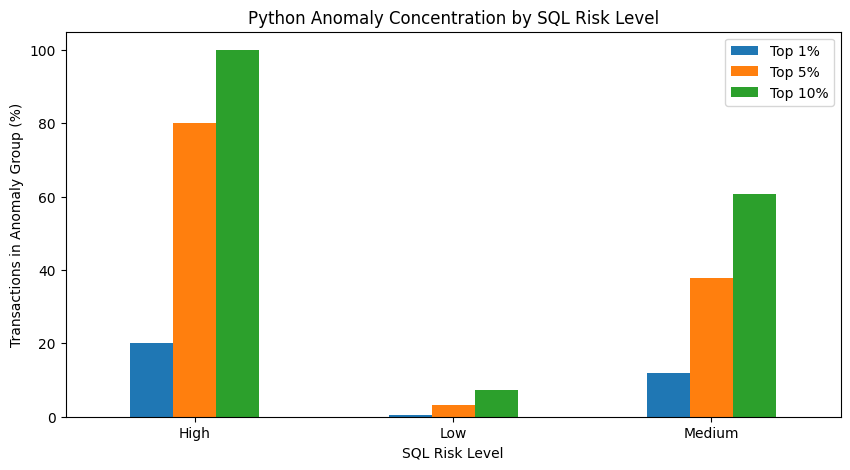

In [108]:
# Plot overlap rates
comparison_rates[
    [
        "top_1pct_rate",
        "top_5pct_rate",
        "top_10pct_rate"
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Python Anomaly Concentration by SQL Risk Level")
plt.xlabel("SQL Risk Level")
plt.ylabel("Transactions in Anomaly Group (%)")
plt.xticks(rotation=0)
plt.legend(["Top 1%", "Top 5%", "Top 10%"])

plt.show()

## 9. Python-Only Anomaly Investigation

Transactions classified as Low risk by the SQL framework but ranked within the top 1% of Isolation Forest anomalies are examined separately.

These observations are particularly relevant because they may reveal unusual multivariate patterns that do not exceed any individual SQL rule threshold.

In [110]:
# Identify model-only anomalies
python_only_anomalies = (
    model_results[
        (model_results["risk_level"] == "Low")
        & (model_results["top_1pct_anomaly"] == 1)
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

print(
    f"SQL Low-risk transactions in Python top 1%: "
    f"{len(python_only_anomalies):,}"
)

SQL Low-risk transactions in Python top 1%: 51


In [112]:
# Review model-only anomalies
python_only_anomalies[
    [
        "SalesOrderID",
        "CustomerID",
        "OrderDate",
        "order_value",
        "days_since_previous_order",
        "prior_order_count",
        "prior_avg_order_value",
        "amount_vs_customer_avg",
        "anomaly_score",
        "risk_reason"
    ]
].head(10)

,SalesOrderID,CustomerID,OrderDate,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,anomaly_score,risk_reason
31322,46640,30096,2012-05-29 23:00:00,37508.56,273.0,1,6.35,5908.35,0.203655,No risk indicators
621,74855,11200,2014-06-21 23:00:00,2.53,11.0,26,62.10,0.04,0.187908,No risk indicators
29413,69483,29766,2014-03-30 23:00:00,1550.50,455.0,1,25.39,61.07,0.177660,No risk indicators
29240,45523,29733,2012-01-28 23:00:00,1614.52,181.0,1,12.70,127.16,0.177289,No risk indicators
27717,50734,29492,2013-04-29 23:00:00,2521.97,182.0,1,23.18,108.81,0.170074,No risk indicators
28949,49064,29691,2012-12-30 23:00:00,9186.18,184.0,1,236.35,38.87,0.165644,No risk indicators
751,72881,11223,2014-05-13 23:00:00,5.51,15.0,25,50.87,0.11,0.163174,No risk indicators
746,70103,11223,2014-04-06 23:00:00,2.53,18.0,20,56.76,0.04,0.161123,No risk indicators
29362,44481,29757,2011-09-30 23:00:00,29689.35,92.0,1,76.18,389.72,0.159366,No risk indicators
1159,71105,11330,2014-04-20 23:00:00,2.53,20.0,21,48.27,0.05,0.159098,No risk indicators


### Behavioural Profile Comparison

Python-only anomalies are compared with the broader SQL Low-risk population to identify which behavioural characteristics make them statistically unusual.

In [113]:
# Compare behavioural profiles
low_risk_normal = model_results[
    (model_results["risk_level"] == "Low")
    & (model_results["top_1pct_anomaly"] == 0)
]

profile_comparison = pd.DataFrame({
    "Python Top 1%": python_only_anomalies[
        [
            "order_value",
            "days_since_previous_order",
            "prior_order_count",
            "prior_avg_order_value",
            "amount_vs_customer_avg"
        ]
    ].median(),

    "Other Low Risk": low_risk_normal[
        [
            "order_value",
            "days_since_previous_order",
            "prior_order_count",
            "prior_avg_order_value",
            "amount_vs_customer_avg"
        ]
    ].median()
}).round(2)

profile_comparison

,Python Top 1%,Other Low Risk
order_value,72.92,1918.26
days_since_previous_order,38.00,156.00
prior_order_count,14.00,1.00
prior_avg_order_value,49.19,2410.63
amount_vs_customer_avg,0.72,0.83


## 10. High-Risk Transaction Validation

The ten transactions classified as High risk by the SQL framework are reviewed alongside their Python anomaly scores and percentiles.

In [115]:
# Review SQL high risk
high_risk_comparison = (
    model_results[
        model_results["risk_level"] == "High"
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

high_risk_comparison[
    [
        "SalesOrderID",
        "CustomerID",
        "order_value",
        "days_since_previous_order",
        "prior_order_count",
        "prior_avg_order_value",
        "amount_vs_customer_avg",
        "transaction_risk_score",
        "anomaly_score",
        "anomaly_percentile",
        "risk_reason"
    ]
]

,SalesOrderID,CustomerID,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,transaction_risk_score,anomaly_score,anomaly_percentile,risk_reason
520,74634,11176,159.64,1.0,25,49.14,3.25,4,0.188887,0.999838,"Rapid repeat (1-7 days), Amount spike"
941,64317,11276,141.38,1.0,10,36.28,3.90,4,0.130367,0.991252,"Rapid repeat (1-7 days), Amount spike"
892,66099,11262,141.38,5.0,14,44.72,3.16,4,0.122243,0.987283,"Rapid repeat (1-7 days), Amount spike"
1588,55101,11498,66.28,5.0,2,7.15,9.27,4,0.115386,0.982747,"Rapid repeat (1-7 days), Amount spike"
2233,60133,11711,76.21,6.0,8,23.03,3.31,4,0.097787,0.970517,"Rapid repeat (1-7 days), Amount spike"
4522,68276,12704,175.70,3.0,2,32.30,5.44,4,0.088773,0.962822,"Rapid repeat (1-7 days), Amount spike"
2059,56087,11641,159.64,0.0,2,50.53,3.16,5,0.082198,0.957152,"Same-day repeat, Amount spike"
1589,55158,11498,87.27,1.0,3,26.86,3.25,4,0.077669,0.952373,"Rapid repeat (1-7 days), Amount spike"
8158,68292,14611,216.13,5.0,2,60.20,3.59,4,0.051113,0.910173,"Rapid repeat (1-7 days), Amount spike"
1659,55462,11505,126.48,5.0,3,38.69,3.27,4,0.048595,0.904503,"Rapid repeat (1-7 days), Amount spike"


## Model Interpretation

- The SQL and Python approaches provide complementary perspectives on transaction risk.

- The SQL framework offers transparent and directly interpretable investigation rules based on transaction velocity, customer spending deviations and geographic inconsistencies.

- Isolation Forest independently confirms that the highest SQL-risk transactions exhibit statistically unusual behavioural profiles, while also identifying additional anomalies that do not exceed any individual SQL threshold.

- Rather than treating the machine-learning model as a fraud classifier, the anomaly score is used as an additional prioritisation signal that can surface unusual transaction combinations for further investigation.

### High-Risk Validation Findings

- The SQL High-risk transactions show strong alignment with the independently generated Isolation Forest anomaly scores.

- All ten High-risk transactions fall within the top 10% of Python anomalies, eight fall within the top 5%, and two fall within the top 1%.

- The strongest cases combine unusually rapid repeat purchasing with transaction values substantially above the customer's historical average.

- This convergence suggests that the transparent SQL behavioural rules are capturing transaction patterns that are also statistically unusual when evaluated through an unsupervised multivariate model.

## 11. Python-Only Anomaly Investigation

Transactions classified as Low risk by the SQL framework but ranked within the top 1% of Isolation Forest anomalies are examined separately.

These transactions may represent unusual combinations of behavioural characteristics that do not exceed any individual SQL rule threshold.

In [116]:
# Identify model-only anomalies
python_only_anomalies = (
    model_results[
        (model_results["risk_level"] == "Low")
        & (model_results["top_1pct_anomaly"] == 1)
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

print(
    f"Python-only top 1% anomalies: "
    f"{len(python_only_anomalies):,}"
)

Python-only top 1% anomalies: 51


In [118]:
# Review model-only anomalies
python_only_anomalies[
    [
        "SalesOrderID",
        "CustomerID",
        "OrderDate",
        "order_value",
        "days_since_previous_order",
        "prior_order_count",
        "prior_avg_order_value",
        "amount_vs_customer_avg",
        "OnlineOrderFlag",
        "anomaly_score",
        "anomaly_percentile"
    ]
].head(10)

,SalesOrderID,CustomerID,OrderDate,order_value,days_since_previous_order,prior_order_count,prior_avg_order_value,amount_vs_customer_avg,OnlineOrderFlag,anomaly_score,anomaly_percentile
31322,46640,30096,2012-05-29 23:00:00,37508.56,273.0,1,6.35,5908.35,0,0.203655,1.000000
621,74855,11200,2014-06-21 23:00:00,2.53,11.0,26,62.10,0.04,1,0.187908,0.999757
29413,69483,29766,2014-03-30 23:00:00,1550.50,455.0,1,25.39,61.07,0,0.177660,0.999514
29240,45523,29733,2012-01-28 23:00:00,1614.52,181.0,1,12.70,127.16,0,0.177289,0.999433
27717,50734,29492,2013-04-29 23:00:00,2521.97,182.0,1,23.18,108.81,0,0.170074,0.999190
28949,49064,29691,2012-12-30 23:00:00,9186.18,184.0,1,236.35,38.87,0,0.165644,0.998704
751,72881,11223,2014-05-13 23:00:00,5.51,15.0,25,50.87,0.11,1,0.163174,0.998623
746,70103,11223,2014-04-06 23:00:00,2.53,18.0,20,56.76,0.04,1,0.161123,0.998299
29362,44481,29757,2011-09-30 23:00:00,29689.35,92.0,1,76.18,389.72,0,0.159366,0.998218
1159,71105,11330,2014-04-20 23:00:00,2.53,20.0,21,48.27,0.05,1,0.159098,0.998137


In [119]:
# Select comparison features
comparison_features = [
    "order_value",
    "days_since_previous_order",
    "prior_order_count",
    "prior_avg_order_value",
    "amount_vs_customer_avg"
]

# Select normal low risk
low_risk_normal = model_results[
    (model_results["risk_level"] == "Low")
    & (model_results["top_1pct_anomaly"] == 0)
]

# Compare median profiles
profile_comparison = pd.DataFrame({
    "Python Top 1%": (
        python_only_anomalies[comparison_features]
        .median()
    ),
    "Other Low Risk": (
        low_risk_normal[comparison_features]
        .median()
    )
}).round(2)

profile_comparison

,Python Top 1%,Other Low Risk
order_value,72.92,1918.26
days_since_previous_order,38.00,156.00
prior_order_count,14.00,1.00
prior_avg_order_value,49.19,2410.63
amount_vs_customer_avg,0.72,0.83


### Python-Only Anomaly Findings

- The Python-only anomalies show a distinct behavioural profile rather than an obviously higher-risk transaction pattern.

- Compared with the broader Low-risk population, these transactions are associated with customers who have substantially more purchasing history, lower typical transaction values and shorter intervals between purchases.

- This highlights an important distinction between statistical anomaly detection and transaction-risk detection. Isolation Forest identifies observations that are unusual within the multivariate feature space, but unusual behaviour is not necessarily suspicious behaviour.

- For this reason, the Python anomaly score is treated as a complementary investigation signal rather than a standalone fraud-risk classification.

## 12. Behaviour-Focused Anomaly Model

The initial Isolation Forest model identified statistically unusual customer profiles, including frequent low-value purchasers that were not necessarily transaction-risk concerns.

A second model is therefore evaluated using a narrower set of behavioural features designed to focus more directly on deviations in transaction timing and customer-specific purchasing behaviour.

In [123]:
# Select behavioural features
behaviour_features = [
    "days_since_previous_order",
    "prior_order_count",
    "amount_vs_customer_avg",
    "OnlineOrderFlag"
]

# Create behaviour dataset
X_behaviour = X_model[behaviour_features].copy()

# Log-transform features
X_behaviour["days_since_previous_order"] = np.log1p(
    X_behaviour["days_since_previous_order"]
)

X_behaviour["prior_order_count"] = np.log1p(
    X_behaviour["prior_order_count"]
)

# Scale behaviour features
behaviour_scaler = StandardScaler()

X_behaviour_scaled = behaviour_scaler.fit_transform(
    X_behaviour
)

X_behaviour_scaled = pd.DataFrame(
    X_behaviour_scaled,
    columns=X_behaviour.columns,
    index=X_behaviour.index
)

# Train behaviour model
behaviour_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42
)

behaviour_model.fit(X_behaviour_scaled)

IsolationForest(n_estimators=300, random_state=42)

In [126]:
# Calculate behaviour scores
model_results["behaviour_anomaly_score"] = (
    -behaviour_model.decision_function(
        X_behaviour_scaled
    )
)

# Rank behaviour anomalies
model_results["behaviour_anomaly_percentile"] = (
    model_results["behaviour_anomaly_score"]
    .rank(pct=True)
)

# Validate high-risk cases
model_results[
    model_results["risk_level"] == "High"
][
    [
        "SalesOrderID",
        "CustomerID",
        "days_since_previous_order",
        "amount_vs_customer_avg",
        "transaction_risk_score",
        "anomaly_percentile",
        "behaviour_anomaly_percentile",
        "risk_reason"
    ]
].sort_values(
    "behaviour_anomaly_percentile",
    ascending=False
)

,SalesOrderID,CustomerID,days_since_previous_order,amount_vs_customer_avg,transaction_risk_score,anomaly_percentile,behaviour_anomaly_percentile,risk_reason
520,74634,11176,1.0,3.25,4,0.999838,0.998623,"Rapid repeat (1-7 days), Amount spike"
941,64317,11276,1.0,3.90,4,0.991252,0.993601,"Rapid repeat (1-7 days), Amount spike"
1588,55101,11498,5.0,9.27,4,0.982747,0.991333,"Rapid repeat (1-7 days), Amount spike"
892,66099,11262,5.0,3.16,4,0.987283,0.989065,"Rapid repeat (1-7 days), Amount spike"
1589,55158,11498,1.0,3.25,4,0.952373,0.985501,"Rapid repeat (1-7 days), Amount spike"
2059,56087,11641,0.0,3.16,5,0.957152,0.984205,"Same-day repeat, Amount spike"
4522,68276,12704,3.0,5.44,4,0.962822,0.980399,"Rapid repeat (1-7 days), Amount spike"
2233,60133,11711,6.0,3.31,4,0.970517,0.978698,"Rapid repeat (1-7 days), Amount spike"
1659,55462,11505,5.0,3.27,4,0.904503,0.960878,"Rapid repeat (1-7 days), Amount spike"
8158,68292,14611,5.0,3.59,4,0.910173,0.950996,"Rapid repeat (1-7 days), Amount spike"


### Behaviour-Focused Model Findings

- The refined behavioural Isolation Forest produces stronger alignment with the SQL risk framework.

- All ten SQL High-risk transactions fall within the top 5% of behavioural anomalies, while three fall within the top 1%.

- The refinement reduces the influence of absolute spending levels and focuses the model more directly on transaction timing, purchasing history and deviations from customer-specific spending behaviour.

- The model is not treated as a fraud classifier. Instead, it provides a complementary statistical prioritisation signal alongside the transparent SQL risk framework.

## 13. Behaviour Model Comparison

The refined anomaly model is compared across SQL risk levels to evaluate how strongly behavioural anomaly rankings concentrate among higher-priority transactions.

In [128]:
# Create behaviour thresholds
model_results["behaviour_top_1pct"] = (
    model_results["behaviour_anomaly_percentile"] >= 0.99
).astype(int)

model_results["behaviour_top_5pct"] = (
    model_results["behaviour_anomaly_percentile"] >= 0.95
).astype(int)

model_results["behaviour_top_10pct"] = (
    model_results["behaviour_anomaly_percentile"] >= 0.90
).astype(int)

# Compare risk levels
behaviour_comparison = (
    model_results
    .groupby("risk_level")
    .agg(
        transactions=("SalesOrderID", "count"),
        avg_behaviour_score=("behaviour_anomaly_score", "mean"),
        top_1pct=("behaviour_top_1pct", "sum"),
        top_5pct=("behaviour_top_5pct", "sum"),
        top_10pct=("behaviour_top_10pct", "sum")
    )
    .round(4)
)

behaviour_comparison

,transactions,avg_behaviour_score,top_1pct,top_5pct,top_10pct
risk_level,,,,,
High,10,0.1532,3,10,10
Low,11745,-0.0645,62,329,768
Medium,591,0.0953,59,279,457


In [129]:
# Calculate overlap rates
behaviour_rates = behaviour_comparison.copy()

behaviour_rates["top_1pct_rate"] = (
    behaviour_rates["top_1pct"]
    / behaviour_rates["transactions"] * 100
).round(2)

behaviour_rates["top_5pct_rate"] = (
    behaviour_rates["top_5pct"]
    / behaviour_rates["transactions"] * 100
).round(2)

behaviour_rates["top_10pct_rate"] = (
    behaviour_rates["top_10pct"]
    / behaviour_rates["transactions"] * 100
).round(2)

behaviour_rates[
    [
        "avg_behaviour_score",
        "top_1pct_rate",
        "top_5pct_rate",
        "top_10pct_rate"
    ]
]

,avg_behaviour_score,top_1pct_rate,top_5pct_rate,top_10pct_rate
risk_level,,,,
High,0.1532,30.00,100.00,100.00
Low,-0.0645,0.53,2.80,6.54
Medium,0.0953,9.98,47.21,77.33


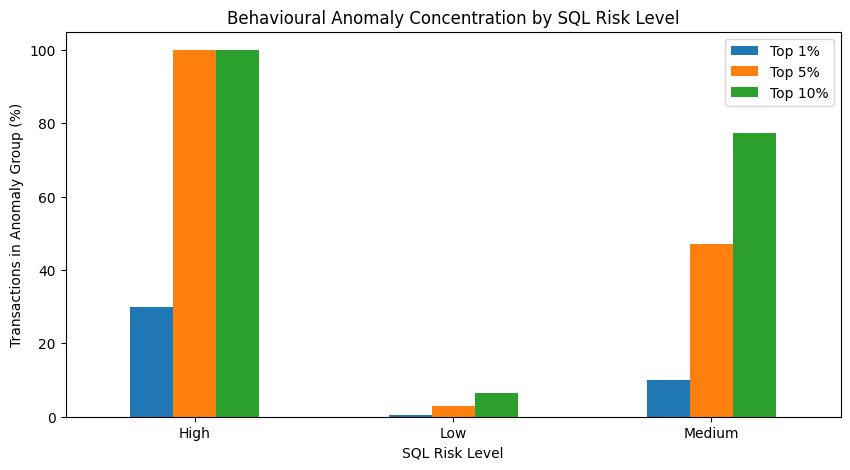

In [130]:
# Plot behaviour overlap
behaviour_rates[
    [
        "top_1pct_rate",
        "top_5pct_rate",
        "top_10pct_rate"
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Behavioural Anomaly Concentration by SQL Risk Level")
plt.xlabel("SQL Risk Level")
plt.ylabel("Transactions in Anomaly Group (%)")
plt.xticks(rotation=0)
plt.legend(["Top 1%", "Top 5%", "Top 10%"])

plt.show()

# Visualization Dashboard Dataset Export

The final analytical dataset combines the complete SQL transaction population with the behavioural anomaly indicators generated in Python.

Transactions without sufficient customer history are retained in the dataset but identified as not eligible for behavioural anomaly scoring.

In [136]:
# Create Tableau dataset
tableau_df = df.copy()

# Mark model eligibility
tableau_df["model_eligible_flag"] = 0

tableau_df.loc[
    model_results.index,
    "model_eligible_flag"
] = 1

# Add behaviour scores
tableau_df.loc[
    model_results.index,
    "behaviour_anomaly_score"
] = model_results["behaviour_anomaly_score"]

tableau_df.loc[
    model_results.index,
    "behaviour_anomaly_percentile"
] = model_results["behaviour_anomaly_percentile"]

# Add anomaly groups
tableau_df["behaviour_top_1pct"] = 0
tableau_df["behaviour_top_5pct"] = 0
tableau_df["behaviour_top_10pct"] = 0

tableau_df.loc[
    model_results.index,
    "behaviour_top_1pct"
] = model_results["behaviour_top_1pct"]

tableau_df.loc[
    model_results.index,
    "behaviour_top_5pct"
] = model_results["behaviour_top_5pct"]

tableau_df.loc[
    model_results.index,
    "behaviour_top_10pct"
] = model_results["behaviour_top_10pct"]

# Add initial scores
tableau_df.loc[
    model_results.index,
    "anomaly_score"
] = model_results["anomaly_score"]

tableau_df.loc[
    model_results.index,
    "anomaly_percentile"
] = model_results["anomaly_percentile"]

# Validate final dataset
print(f"Total Rows: {tableau_df.shape[0]:,}")
print(f"Total Columns: {tableau_df.shape[1]}")
print(
    f"Model Eligible: "
    f"{tableau_df['model_eligible_flag'].sum():,}"
)

Total Rows: 31,465
Total Columns: 45
Model Eligible: 12,346


In [138]:
# Review final fields
tableau_df[
    [
        "SalesOrderID",
        "CustomerID",
        "order_value",
        "risk_level",
        "transaction_risk_score",
        "model_eligible_flag",
        "behaviour_anomaly_score",
        "behaviour_anomaly_percentile",
        "behaviour_top_1pct",
        "behaviour_top_5pct",
        "behaviour_top_10pct"
    ]
].head(6)

,SalesOrderID,CustomerID,order_value,risk_level,transaction_risk_score,model_eligible_flag,behaviour_anomaly_score,behaviour_anomaly_percentile,behaviour_top_1pct,behaviour_top_5pct,behaviour_top_10pct
0,43793,11000,3756.99,Low,0,0,NaN,NaN,0,0,0
1,51522,11000,2587.88,Low,0,1,-0.119688,0.265066,0,0,0
2,57418,11000,2770.27,Low,0,1,-0.090122,0.406204,0,0,0
3,43767,11001,3729.36,Low,0,0,NaN,NaN,0,0,0
4,51493,11001,2674.02,Low,0,1,-0.115187,0.294913,0,0,0
5,72773,11001,650.80,Low,0,1,-0.026126,0.715940,0,0,0


In [140]:
# Export dataset
tableau_df.to_csv(
    "fraud_analytics_tableau.csv",
    index=False
)

# Confirm export
print(
    f"Exported {len(tableau_df):,} transactions "
    f"for Tableau."
)

Exported 31,465 transactions for Tableau.
